In [1]:
#train pipleline


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter

In [61]:
N_BINS = 80

SIGMA = 1.0

EPS = 1e-10

SKIP_TIMESTEPS = 50

GAUSSIAN_KERNEL = (5, 5)

THRESHOLD_K = 1.0


In [62]:
def get_input_data(
    pkl_path,
    layer_name,
):
    """
    Load the 2D trajectory dataset.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])

    prediction = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    positions = prediction.copy()

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        positions = positions[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [63]:
def get_arena_bounds(positions):
    """
    Compute global arena bounds across all trajectories.

    Parameters
    ----------
    positions : ndarray
        Shape (n_traj, T, 2)

    Returns
    -------
    bounds : tuple
        (xmin, xmax, ymin, ymax)
    """

    xmin = np.min(positions[:, :, 0])
    xmax = np.max(positions[:, :, 0])

    ymin = np.min(positions[:, :, 1])
    ymax = np.max(positions[:, :, 1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [64]:
def get_arena_bounds(positions_list):
    """
    Compute global arena bounds shared across every trajectory.
    """

    all_positions = np.concatenate(positions_list, axis=0)

    xmin = np.min(all_positions[:,0])
    xmax = np.max(all_positions[:,0])

    ymin = np.min(all_positions[:,1])
    ymax = np.max(all_positions[:,1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [65]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every (x, y) position sample to a spatial bin.

    Parameters
    ----------
    positions : ndarray
        Shape (T, 2)

    bins : int
        Number of bins along each dimension.

    bounds : tuple
        (xmin, xmax, ymin, ymax)

    Returns
    -------
    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    x_edges : ndarray
        Bin edges along x.

    y_edges : ndarray
        Bin edges along y.
    """

    xmin, xmax, ymin, ymax = bounds

    x_edges = np.linspace(xmin, xmax, bins + 1)
    y_edges = np.linspace(ymin, ymax, bins + 1)

    x_bin = np.digitize(
        positions[:, 0],
        x_edges,
    ) - 1

    y_bin = np.digitize(
        positions[:, 1],
        y_edges,
    ) - 1

    # Keep indices inside the grid
    x_bin = np.clip(x_bin, 0, bins - 1)
    y_bin = np.clip(y_bin, 0, bins - 1)

    return x_bin, y_bin, x_edges, y_edges

In [66]:
def compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D occupancy maps.

    Parameters
    ----------
    x_bin : ndarray
    y_bin : ndarray

    Returns
    -------
    count_occupancy : (bins,bins)

    probability_occupancy : (bins,bins)
    """

    count_occupancy = np.zeros((bins, bins), dtype=float)

    # Count visits
    for xb, yb in zip(x_bin, y_bin):
        count_occupancy[yb, xb] += 1

    total = np.sum(count_occupancy)

    if total > 0:
        probability_occupancy = count_occupancy / total
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [67]:
def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
    threshold_k=THRESHOLD_K,
):
    """
    Compute activity maps for one neuron.

    Activity below mean + k*std is removed.
    """

    amplitude = np.abs(activity)

    # ---------------------------------
    # Threshold activity
    # ---------------------------------
    threshold = amplitude.mean() + threshold_k * amplitude.std()

    amplitude = np.where(
        amplitude >= threshold,
        amplitude,
        0.0,
    )

    real = np.real(activity)

    amplitude_activity = np.zeros((bins, bins), dtype=float)
    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):
        amplitude_activity[yb, xb] += a
        real_activity[yb, xb] += r

    return (
        amplitude_activity,
        real_activity,
        threshold,
    )

In [ ]:
"""

def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
):

"""
"""
Compute 2D activity maps for ONE neuron.

    Parameters
    ----------
    activity : ndarray
        Shape (T,)

    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    Returns
    -------
    amplitude_activity : (bins, bins)

    real_activity : (bins, bins) 

"""

"""
    amplitude = np.abs(activity)

    real = np.real(activity)

    amplitude_activity = np.zeros((bins, bins), dtype=float)

    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):

        amplitude_activity[yb, xb] += a

        real_activity[yb, xb] += r

    return amplitude_activity, real_activity """

'\n    amplitude = np.abs(activity)\n\n    real = np.real(activity)\n\n    amplitude_activity = np.zeros((bins, bins), dtype=float)\n\n    real_activity = np.zeros((bins, bins), dtype=float)\n\n    for a, r, xb, yb in zip(\n        amplitude,\n        real,\n        x_bin,\n        y_bin,\n    ):\n\n        amplitude_activity[yb, xb] += a\n\n        real_activity[yb, xb] += r\n\n    return amplitude_activity, real_activity\n'

In [68]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map.

    Works for both 1D and 2D arrays.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [69]:
from scipy.signal import convolve2d


def matlab_style_gauss2D(shape=(5, 5), sigma=1.0):
    """
    2D Gaussian mask equivalent to MATLAB's

        fspecial('gaussian', shape, sigma)

    Parameters
    ----------
    shape : tuple
        Size of the Gaussian kernel.

    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    h : ndarray
        Normalized Gaussian kernel.
    """

    m, n = [(ss - 1.) / 2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x + y*y) / (2.0 * sigma * sigma))

    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h


def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
    kernel_shape=GAUSSIAN_KERNEL,
):
    """
    Smooth a firing-rate map using a MATLAB-style Gaussian kernel.

    Parameters
    ----------
    firing_rate_map : ndarray
        2D firing-rate map.

    sigma : float
        Gaussian standard deviation.

    kernel_shape : tuple
        Kernel size used by MATLAB's fspecial.
    """

    kernel = matlab_style_gauss2D(
        shape=kernel_shape,
        sigma=sigma,
    )

    smoothed = convolve2d(
        firing_rate_map,
        kernel,
        mode="same",
        boundary="symm",
    )

    return smoothed

In [70]:
def spatial_information(rate_map, occupancy_map):
    """
    Spatial Information (bits/spike)

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map

    occupancy_map : ndarray
        Count or probability occupancy
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
        & (rate_map > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    r_bar = np.sum(p * r)

    if r_bar <= EPS:
        return np.nan

    ratio = r / r_bar

    return np.sum(
        p * ratio * np.log2(ratio)
    )

In [71]:
def sparsity(rate_map, occupancy_map):
    """
    Population sparsity
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r**2)

    if mean_r2 <= EPS:
        return np.nan

    return (mean_r**2) / mean_r2

In [72]:
def evaluate_place_cell(rate_map, occupancy_map):
    """
    Compute place-cell metrics from a raw firing-rate map.
    """

    return {
        "Spatial Information": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

#main


In [73]:
import pickle
import numpy as np

layer_name = "d4"

trajectory_results_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    trajectory_results_path,
    layer_name,
)

In [74]:
print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [75]:
bounds = get_arena_bounds(
    [positions[i] for i in range(len(positions))]
)

results = []

traj = 0        # choose trajectory

x_bin, y_bin, _, _ = bin_positions(
    positions[traj],
    bins=N_BINS,
    bounds=bounds,
)

count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
)

n_neurons = activations.shape[2]

for neuron in range(n_neurons):

    activity = activations[traj, :, neuron]

    amp_map, _ = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
        bins=N_BINS,
    )

    rate_map = compute_firing_rate_map(
        amp_map,
        count_occ,
    )

    rate_map = smooth_firing_rate_map(rate_map)

    si = spatial_information(
        rate_map,
        count_occ,
    )

    sp = sparsity(
        rate_map,
        count_occ,
    )

    results.append({
        "Neuron": neuron,
        "SI": si,
        "Sparsity": sp,
        "Rate Map": rate_map,
    })

ValueError: too many values to unpack (expected 2)

In [54]:
results = sorted(
    results,
    key=lambda x: x["SI"],
    reverse=True,
)

top20 = results[:20]

In [55]:
for r in top20:
    print(
        f"Neuron {r['Neuron']:3d} | "
        f"SI = {r['SI']:.3f} | "
        f"Sparsity = {r['Sparsity']:.3f}"
    )

Neuron  53 | SI = 3.745 | Sparsity = 0.068
Neuron  63 | SI = 3.406 | Sparsity = 0.082
Neuron  79 | SI = 3.340 | Sparsity = 0.093
Neuron  69 | SI = 3.262 | Sparsity = 0.094
Neuron  83 | SI = 3.243 | Sparsity = 0.095
Neuron   2 | SI = 3.200 | Sparsity = 0.099
Neuron  76 | SI = 3.176 | Sparsity = 0.094
Neuron  78 | SI = 3.163 | Sparsity = 0.102
Neuron  14 | SI = 3.135 | Sparsity = 0.106
Neuron  23 | SI = 3.129 | Sparsity = 0.102
Neuron  56 | SI = 3.122 | Sparsity = 0.099
Neuron  27 | SI = 3.072 | Sparsity = 0.113
Neuron   7 | SI = 3.062 | Sparsity = 0.107
Neuron  84 | SI = 3.006 | Sparsity = 0.118
Neuron  12 | SI = 2.974 | Sparsity = 0.118
Neuron  32 | SI = 2.956 | Sparsity = 0.120
Neuron  39 | SI = 2.925 | Sparsity = 0.107
Neuron  71 | SI = 2.888 | Sparsity = 0.122
Neuron  68 | SI = 2.869 | Sparsity = 0.130
Neuron  37 | SI = 2.864 | Sparsity = 0.117


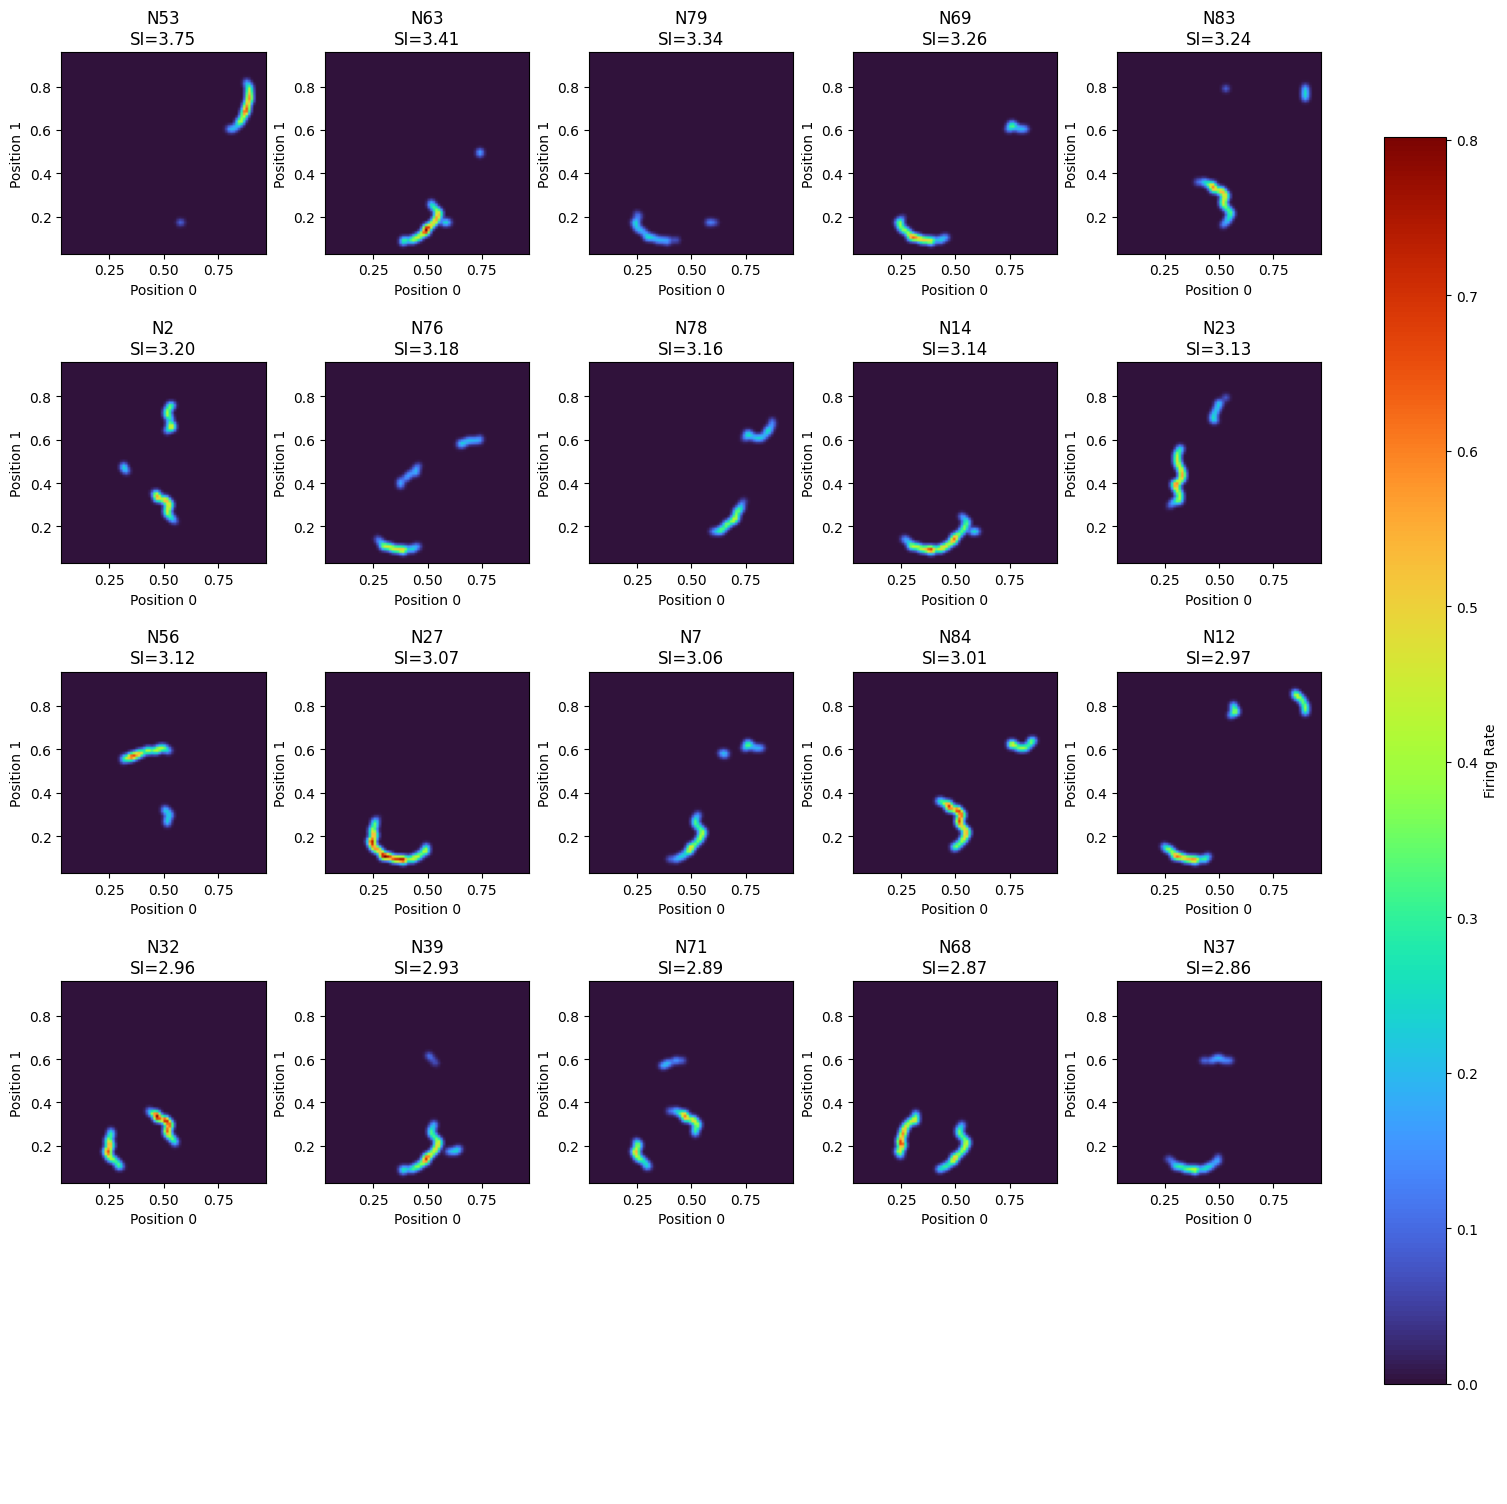

In [56]:
fig, axes = plt.subplots(
    5,
    5,
    figsize=(15,15),
    constrained_layout=True,
)

axes = axes.ravel()

for i in range(25):

    ax = axes[i]

    if i >= len(top20):
        ax.axis("off")
        continue

    neuron = top20[i]

    vmax = max(
    np.max(r["Rate Map"])
    for r in top20)

    im = ax.imshow(
    neuron["Rate Map"],
    origin="lower",
    extent=[bounds[0], bounds[1], bounds[2], bounds[3]],
    aspect="equal",
    cmap="turbo",
    vmin=0,
    vmax=vmax,
        )

    ax.set_title(
        f"N{neuron['Neuron']}\n"
        f"SI={neuron['SI']:.2f}"
    )

    ax.set_xlabel("Position 0")
    ax.set_ylabel("Position 1")

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
)

cbar.set_label("Firing Rate")

plt.show()